# Pipeline — April 7

Improvements over `march30_week.ipynb`:
- **MLE initialization**: Nelder-Mead finds the posterior peak first; walkers start in a tight ball around it instead of uniform over the full prior — eliminates most burn-in waste
- **Multiple MLE seeds**: tries 4 starting points to avoid local minima (age–extinction degeneracy)
- **DEMove + DESnookerMove**: handles correlated parameters (age–Av anti-correlation) better than the default StretchMove
- **Adaptive convergence stopping**: checks autocorr time every 200 steps, stops when converged rather than running a fixed number of steps
- **Deliberate test sample**: subgiants + F-stars + K-dwarfs instead of head(N)
- **Chi² sanity check**: verifies the likelihood is well-behaved before running anything

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML
from astroquery.gaia import Gaia
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize
from isochrones.mist import MIST_Isochrone
import emcee
import astropy.units as u
from dust_extinction.parameter_averages import F99

mist = MIST_Isochrone()

## 1. Helper Functions

In [83]:
def get_distance_info(ra, dec, radius=2/3600):
    """Query Gaia DR3 near (ra, dec). Returns (distance_pc, distance_err_pc)."""
    query = f"""
    SELECT TOP 1 parallax, parallax_error
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra}, {dec}, {radius})
    ) = 1
    AND parallax > 0
    """
    job = Gaia.launch_job(query)
    result = job.get_results()
    if len(result) == 0:
        return np.nan, np.nan
    plx     = float(result['parallax'][0])
    plx_err = float(result['parallax_error'][0])
    if plx <= 0:
        return np.nan, np.nan
    dist_pc     = 1000.0 / plx
    dist_err_pc = 1000.0 * plx_err / plx**2
    return dist_pc, dist_err_pc


def apparent_to_absolute(m_app, distance_pc):
    return m_app - 5.0 * np.log10(distance_pc / 10.0)


def add_dist_err(phot_err, dist_pc, dist_err_pc):
    sigma_mu = 5.0 * dist_err_pc / (dist_pc * np.log(10))
    return np.sqrt(phot_err**2 + sigma_mu**2)

## 2. Load and Merge Data

In [84]:
df1 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Target_List.csv")
df2 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Photometry_List.csv")

df1 = df1.drop_duplicates(subset="hostname")
df2 = df2.drop_duplicates(subset="hostname")

merged = pd.merge(df1, df2, on="hostname", how="inner")
merged["ra"]  = merged["ra_x"]
merged["dec"] = merged["dec_x"]
merged = merged.drop(columns=["ra_x", "ra_y", "dec_x", "dec_y", "pl_name_y"])

want_cols = [
    "hostname", "st_teff", "st_logg", "st_age", "st_met",
    "ra", "dec",
    "gaia_Gmag", "e_gaiamag",
    "gaia_BPmag", "gaia_RPmag",
    "Jmag", "Hmag", "Kmag",
    "e_Jmag", "e_Hmag", "e_Kmag",
]
merged = merged[[c for c in want_cols if c in merged.columns]]

merged = merged.dropna(subset=[
    "st_teff", "st_age", "st_met", "ra", "dec",
    "gaia_Gmag", "gaia_BPmag", "gaia_RPmag",
    "Jmag", "Hmag", "Kmag",
])

merged["e_gaiamag"] = merged["e_gaiamag"].fillna(0.01)
merged["e_Jmag"]    = merged["e_Jmag"].fillna(0.03)
merged["e_Hmag"]    = merged["e_Hmag"].fillna(0.03)
merged["e_Kmag"]    = merged["e_Kmag"].fillna(0.03)

print(f"Stars with complete photometry: {len(merged)}")

# query Gaia for parallax + error
merged_sample = merged.head(300).copy()

dist_results = merged_sample.apply(
    lambda row: get_distance_info(row["ra"], row["dec"]), axis=1
)
merged_sample["distance_pc"]     = [r[0] for r in dist_results]
merged_sample["distance_err_pc"] = [r[1] for r in dist_results]

merged_sample = merged_sample.dropna(subset=["distance_pc"])
merged_sample = merged_sample[merged_sample["distance_pc"] <= 100].copy()
merged_sample = merged_sample.reset_index(drop=True)

print(f"Stars within 100 pc: {len(merged_sample)}")
display(HTML(merged_sample.head(10).to_html()))

Stars with complete photometry: 2824
Stars within 100 pc: 61


,hostname,st_teff,st_logg,st_age,st_met,ra,dec,gaia_Gmag,e_gaiamag,gaia_BPmag,gaia_RPmag,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag,distance_pc,distance_err_pc
0,HIP 65 A,4590.0,4.611,4.10,0.18,0.185606,-54.830823,10.588468,0.000446,11.212916,9.835994,8.922,8.400,8.290,0.019,0.031,0.025,61.865322,0.035680
1,TOI-198,3650.0,4.750,5.30,-0.70,2.271509,-27.121745,10.915721,0.000655,11.910542,9.930160,8.655,8.143,7.856,0.024,0.026,0.021,23.776037,0.018320
2,Gliese 12,3296.0,5.210,7.00,-0.32,3.957914,13.557617,11.399355,0.001756,12.830511,10.227193,8.619,8.068,7.807,0.020,0.026,0.020,12.166368,0.004818
3,HD 1397,5521.0,3.823,4.51,0.29,4.447163,-66.358929,7.605658,0.000278,7.984488,7.055598,6.442,6.090,5.988,0.020,0.049,0.018,80.042045,0.108865
4,TOI-260,4026.0,4.450,15.90,-0.47,4.773018,-9.966150,9.316666,0.000458,10.124876,8.434608,7.376,6.710,6.549,0.020,0.031,0.021,20.211922,0.007260
5,TOI-178,4316.0,4.450,6.00,-0.23,7.302011,-30.454116,11.157550,0.000890,11.839834,10.360156,9.372,8.761,8.656,0.021,0.023,0.021,62.892960,0.122007
6,HD 3167,5261.0,4.530,7.80,0.04,8.740149,4.380721,8.772422,0.000265,9.178295,8.196435,7.548,7.203,7.066,0.032,0.038,0.020,47.312007,0.041852
7,TOI-1470,3709.0,4.770,1.30,0.00,10.089143,61.213387,12.542486,0.000285,13.669263,11.486450,10.154,9.514,9.283,0.024,0.032,0.020,51.739129,0.034937
8,TOI-244,3433.0,4.660,7.00,-0.39,10.569754,-36.717974,11.548954,0.001017,12.933047,10.387751,8.827,8.251,7.970,0.023,0.033,0.029,22.075149,0.013174
9,LHS 1140,3096.0,5.041,5.00,-0.15,11.248632,-15.274109,12.653936,0.000356,14.414495,11.383511,9.612,9.092,8.821,0.023,0.026,0.024,14.963621,0.010719


## 3. Build MIST Interpolation Grid

In [85]:
age_grid  = np.linspace(6.0, 10.2, 60)
feh_grid  = np.linspace(-2.5,  0.5, 31)
mass_grid = np.linspace(0.1,  10.0, 200)

bands_interp = ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag', 'Teff', 'logg']
shape = (len(age_grid), len(feh_grid), len(mass_grid))
cubes = {b: np.full(shape, np.nan) for b in bands_interp}

print("Building MIST grid (this takes a few minutes)...")
for i, age in enumerate(age_grid):
    for j, feh in enumerate(feh_grid):
        iso = mist.isochrone(age, feh)
        if iso.empty:
            continue
        iso = iso.sort_values("initial_mass")
        for b in bands_interp:
            if b not in iso.columns:
                continue
            cubes[b][i, j, :] = np.interp(
                mass_grid, iso["initial_mass"], iso[b],
                left=np.nan, right=np.nan
            )

interpolators = {}
for b in bands_interp:
    interpolators[b] = RegularGridInterpolator(
        (age_grid, feh_grid, mass_grid),
        cubes[b],
        bounds_error=False,
        fill_value=np.nan
    )

print("Done. Interpolators:", list(interpolators.keys()))

# solar sanity check
test = [[9.66, 0.0, 1.0]]
print(f"Solar check  G={interpolators['G_mag'](test)[0]:.2f}  "
      f"logg={interpolators['logg'](test)[0]:.2f}  "
      f"Teff={interpolators['Teff'](test)[0]:.0f} K")

Building MIST grid (this takes a few minutes)...
Done. Interpolators: ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag', 'Teff', 'logg']
Solar check  G=4.55  logg=4.42  Teff=5847 K


## 4. Likelihood and Priors

In [86]:
ext_model = F99(Rv=3.1)

fit_bands = ["G", "BP", "RP", "J", "H", "K"]
band_map  = {"G": "G_mag", "BP": "BP_mag", "RP": "RP_mag",
             "J": "J_mag",  "H":  "H_mag",  "K":  "K_mag"}

band_wavelengths = {
    "G":  6231, "BP": 5323, "RP": 7725,
    "J":  12350, "H": 16620, "K": 21590,
}

ext_coeffs = {b: float(ext_model(band_wavelengths[b] * u.AA)) for b in fit_bands}
print("Extinction A(λ)/A(V):")
for b, c in ext_coeffs.items():
    print(f"  {b:3s}: {c:.4f}")

# systematic error floor per band for cool stars (Teff < 4000K)
# RP and H are poorly modeled by MIST/Phoenix for M-dwarfs:
#   - RP (~7725Å): TiO molecular bands underestimated
#   - H (~1.66µm): H2O opacity wrong for cool atmospheres
# Adding 0.05 mag in quadrature prevents these bands from dominating chi²
# and driving the fitter to unphysical solutions
MDWARF_TEFF_THRESHOLD = 4000   # K
MDWARF_SYSTEMATIC     = {      # extra error added in quadrature for Teff < threshold
    "G": 0.00, "BP": 0.00, "RP": 0.05,
    "J": 0.00, "H":  0.05, "K":  0.00,
}


def chi2_model(params, star):
    logage, mass, Av, feh = params
    feh_c = np.clip(feh, feh_grid.min(), feh_grid.max())
    pt = [[logage, feh_c, mass]]

    y    = np.array([star["photometry"][b] for b in fit_bands])
    yerr = np.array([star["phot_err"][b]   for b in fit_bands])

    # add systematic floor for cool stars
    if star["Teff"] < MDWARF_TEFF_THRESHOLD:
        yerr = np.sqrt(yerr**2 + np.array([MDWARF_SYSTEMATIC[b]**2 for b in fit_bands]))

    model_mags = np.array([interpolators[band_map[b]](pt)[0] for b in fit_bands])
    if np.any(np.isnan(model_mags)):
        return 1e10

    A_lambda       = np.array([ext_coeffs[b] * Av for b in fit_bands])
    model_mags_ext = model_mags + A_lambda

    chi2_phot = np.sum(((y - model_mags_ext) / yerr) ** 2)

    Teff_model = interpolators["Teff"](pt)[0]
    if np.isnan(Teff_model):
        return 1e10
    chi2_teff = ((star["Teff"] - Teff_model) / star["teff_err"]) ** 2

    chi2_logg = 0.0
    if not np.isnan(star["logg"]):
        logg_model = interpolators["logg"](pt)[0]
        if not np.isnan(logg_model):
            chi2_logg = ((star["logg"] - logg_model) / 0.2) ** 2

    return chi2_phot + chi2_teff + chi2_logg


def log_prior(params, star):
    logage, mass, Av, feh = params

    if not (6.0  <= logage <= 10.2):                   return -np.inf
    if not (0.1  <= mass   <= 2.5):                    return -np.inf
    if not (0.0  <= Av     <= 0.15):                   return -np.inf
    if not (feh_grid.min() <= feh <= feh_grid.max()):  return -np.inf

    log_prior_age = 0.0

    if mass < 0.5:
        log_prior_mass = -1.3 * np.log(mass)
    else:
        log_prior_mass = -2.3 * np.log(mass)

    d         = star["distance_pc"]
    Av_expect = 0.0007 * d
    Av_sigma  = 0.02 + 0.0005 * d
    log_prior_Av = -0.5 * ((Av - Av_expect) / Av_sigma) ** 2

    log_prior_feh = -0.5 * ((feh - star["feh"]) / star["feh_err"]) ** 2

    return log_prior_age + log_prior_mass + log_prior_Av + log_prior_feh


def log_probability(params, star):
    lp = log_prior(params, star)
    if not np.isfinite(lp):
        return -np.inf
    return lp - 0.5 * chi2_model(params, star)

Extinction A(λ)/A(V):
  G  : 0.8214
  BP : 1.0247
  RP : 0.5865
  J  : 0.2620
  H  : 0.1633
  K  : 0.1121


## 5. Star Dictionary Builder

In [87]:
def init_mass_from_teff(teff):
    return float(np.clip((teff / 5778.0) ** 1.8, 0.15, 2.4))


def row_to_star(row):
    d     = float(row["distance_pc"])
    d_err = float(row.get("distance_err_pc", 0.0))
    if np.isnan(d_err):
        d_err = 0.0

    e_G  = max(float(row.get("e_gaiamag", 0.01)), 0.003)
    e_BP = max(e_G * 1.5, 0.015)
    e_RP = max(e_G * 1.2, 0.010)
    e_J  = max(float(row.get("e_Jmag", 0.03)), 0.01)
    e_H  = max(float(row.get("e_Hmag", 0.03)), 0.01)
    e_K  = max(float(row.get("e_Kmag", 0.03)), 0.01)

    phot_err = {
        "G":  add_dist_err(e_G,  d, d_err),
        "BP": add_dist_err(e_BP, d, d_err),
        "RP": add_dist_err(e_RP, d, d_err),
        "J":  add_dist_err(e_J,  d, d_err),
        "H":  add_dist_err(e_H,  d, d_err),
        "K":  add_dist_err(e_K,  d, d_err),
    }

    logg_val = row.get("st_logg", np.nan)
    logg_val = float(logg_val) if pd.notna(logg_val) else np.nan

    return {
        "hostname":    row["hostname"],
        "distance_pc": d,
        "photometry": {
            "G":  apparent_to_absolute(row["gaia_Gmag"],  d),
            "BP": apparent_to_absolute(row["gaia_BPmag"], d),
            "RP": apparent_to_absolute(row["gaia_RPmag"], d),
            "J":  apparent_to_absolute(row["Jmag"],       d),
            "H":  apparent_to_absolute(row["Hmag"],       d),
            "K":  apparent_to_absolute(row["Kmag"],       d),
        },
        "phot_err": phot_err,
        "Teff":     float(row["st_teff"]),
        "teff_err": 100.0,
        "logg":     logg_val,
        "feh":      float(row.get("st_met", 0.0)),
        "feh_err":  0.10,
        "age_true": float(row["st_age"]),
    }

## 6. Chi² Sanity Check

Run this before any MCMC. If chi² at a reasonable starting point is huge, the likelihood has a bug — better to catch it on 1 star than after a 3000-star run.

In [88]:
# pick the star in the sample closest to solar (Teff nearest 5778)
solar_idx  = (merged_sample["st_teff"] - 5778).abs().idxmin()
solar_row  = merged_sample.loc[solar_idx]
solar_star = row_to_star(solar_row)

print(f"Sanity check star: {solar_star['hostname']}")
print(f"  Teff={solar_star['Teff']:.0f} K  logg={solar_star['logg']:.2f}  "
      f"[Fe/H]={solar_star['feh']:.2f}  d={solar_star['distance_pc']:.1f} pc")
print()

# evaluate chi2 at solar parameters
chi2_solar = chi2_model([9.66, 1.0, 0.001, 0.0], solar_star)
print(f"Chi2 at solar params (logage=9.66, M=1.0, Av=0.001, feh=0.0): {chi2_solar:.2f}")
print("  (should be < ~30 for a G-dwarf; if > 100 something is wrong)")
print()

# also print observed vs model mags at solar params
print("Band  |  Observed Abs Mag  |  Model Mag  |  Diff")
print("-" * 52)
for b in fit_bands:
    obs   = solar_star["photometry"][b]
    model = interpolators[band_map[b]]([[9.66, 0.0, 1.0]])[0]
    print(f"  {b:3s}  |  {obs:+.3f}             |  {model:+.3f}     |  {obs-model:+.3f}")

Sanity check star: HD 21520
  Teff=5871 K  logg=4.42  [Fe/H]=0.05  d=79.4 pc

Chi2 at solar params (logage=9.66, M=1.0, Av=0.001, feh=0.0): 38.78
  (should be < ~30 for a G-dwarf; if > 100 something is wrong)

Band  |  Observed Abs Mag  |  Model Mag  |  Diff
----------------------------------------------------
  G    |  +4.526             |  +4.545     |  -0.019
  BP   |  +4.833             |  +4.849     |  -0.016
  RP   |  +4.050             |  +4.076     |  -0.026
  J    |  +3.548             |  +3.572     |  -0.024
  H    |  +3.264             |  +3.251     |  +0.013
  K    |  +3.207             |  +3.216     |  -0.009


## 7. MCMC Fitter

Key changes:
- **MLE first** via Nelder-Mead (4 seeds)
- **StretchMove(a=1.5)** — tighter steps than default a=2.0
- **Fixed steps + Gelman-Rubin R-hat** instead of 50×τ criterion.
  The 50×τ criterion is wrong for flat/wide posteriors (MS stars): τ grows proportionally
  with chain length because the sampler keeps exploring. R-hat splits the post-burnin
  chain in two halves and checks they give the same distribution — R-hat < 1.1 = converged.
- Stars flagged **"Unconstrained"** when age 68% CI width > 5 Gyr — that's physics, not failure.

In [89]:
NWALKERS = 32
NSTEPS   = 8000
BURNIN   = 2000


def gelman_rubin(chain):
    """Split-chain R-hat. R-hat < 1.2 acceptable; < 1.1 ideal."""
    nsteps, nwalkers, ndim = chain.shape
    mid = nsteps // 2
    chains = np.concatenate([chain[:mid], chain[mid:]], axis=1)
    n  = chains.shape[0]
    m  = chains.shape[1]
    chain_means = chains.mean(axis=0)
    grand_mean  = chain_means.mean(axis=0)
    B = n / (m - 1) * ((chain_means - grand_mean) ** 2).sum(axis=0)
    W = ((chains - chain_means[None]) ** 2).sum(axis=(0, 1)) / (m * (n - 1))
    var_hat = (n - 1) / n * W + B / n
    rhat = np.sqrt(var_hat / (W + 1e-30))
    return rhat


def find_mle(star):
    d          = star["distance_pc"]
    mass_guess = init_mass_from_teff(star["Teff"])
    seeds = [
        [9.0,  mass_guess,       0.0007 * d, star["feh"]],
        [8.0,  mass_guess,       0.0007 * d, star["feh"]],
        [7.5,  mass_guess * 0.9, 0.005,      star["feh"]],
        [9.5,  mass_guess * 1.1, 0.0007 * d, star["feh"]],
    ]
    best_p, best_val = None, np.inf
    for p0 in seeds:
        p0[0] = np.clip(p0[0], 6.1, 10.1)
        p0[1] = np.clip(p0[1], 0.11, 2.4)
        p0[2] = np.clip(p0[2], 0.0,  0.14)
        p0[3] = np.clip(p0[3], feh_grid.min() + 0.01, feh_grid.max() - 0.01)
        if not np.isfinite(log_probability(p0, star)):
            continue
        try:
            res = minimize(
                lambda p: -log_probability(p, star), p0,
                method="Nelder-Mead",
                options={"maxiter": 3000, "xatol": 1e-4, "fatol": 1e-4},
            )
            if res.fun < best_val:
                best_val = res.fun
                best_p   = res.x
        except Exception:
            continue
    if best_p is None:
        best_p = np.array(seeds[0])
    best_p[0] = np.clip(best_p[0], 6.1, 10.1)
    best_p[1] = np.clip(best_p[1], 0.11, 2.4)
    best_p[2] = np.clip(best_p[2], 0.0,  0.14)
    best_p[3] = np.clip(best_p[3], feh_grid.min() + 0.01, feh_grid.max() - 0.01)
    return best_p


def fit_star_emcee(star, nwalkers=NWALKERS, nsteps=NSTEPS, burnin=BURNIN):
    ndim = 4

    mle      = find_mle(star)
    mle_chi2 = chi2_model(mle, star)
    print(f"  MLE: logage={mle[0]:.2f}  mass={mle[1]:.3f}  "
          f"Av={mle[2]:.4f}  feh={mle[3]:.3f}  chi2={mle_chi2:.1f}")

    scale = np.array([0.05, 0.05, 0.002, 0.03])
    pos   = mle + scale * np.random.randn(nwalkers, ndim)
    pos[:, 0] = np.clip(pos[:, 0], 6.1, 10.1)
    pos[:, 1] = np.clip(pos[:, 1], 0.11, 2.4)
    pos[:, 2] = np.clip(pos[:, 2], 0.0,  0.14)
    pos[:, 3] = np.clip(pos[:, 3], feh_grid.min() + 0.01, feh_grid.max() - 0.01)

    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_probability,
        args=(star,),
        moves=emcee.moves.StretchMove(a=1.5),
    )
    sampler.run_mcmc(pos, nsteps, progress=True)

    acc      = float(np.mean(sampler.acceptance_fraction))
    chain    = sampler.get_chain(discard=burnin)
    rhat     = gelman_rubin(chain)
    max_rhat = float(np.max(rhat))
    converged = bool(max_rhat < 1.2)
    print(f"  Acceptance: {acc:.3f}  |  Max R-hat: {max_rhat:.4f}  "
          f"({'OK' if converged else 'WARN >1.2'})  "
          f"R-hat per param: {np.round(rhat, 3)}")

    samples   = sampler.get_chain(discard=burnin, flat=True)
    age_samps = 10 ** samples[:, 0] / 1e9

    age_lo    = float(np.percentile(age_samps, 16))
    age_hi    = float(np.percentile(age_samps, 84))
    age_width = age_hi - age_lo
    unconstrained = bool(age_width > 5.0)

    # quality flag:
    # 0 = good
    # 1 = bad photometric fit or genuinely stuck chain
    #     threshold: mle_chi2 > 50 (after systematic floor applied) catches true failures
    #     R-hat > 2.0 catches genuinely multimodal/stuck chains (not just slow mixing)
    #     acc < 0.10 catches frozen walkers
    # 2 = unconstrained flat posterior (MS star with no age info — not a failure)
    if mle_chi2 > 50 or acc < 0.10 or max_rhat > 2.0:
        quality = 1
    elif unconstrained:
        quality = 2
    else:
        quality = 0

    return {
        "hostname":       star["hostname"],
        "age_catalog":    star["age_true"],
        "age_median":     float(np.median(age_samps)),
        "age_err":        float(np.std(age_samps)),
        "age_lo":         age_lo,
        "age_hi":         age_hi,
        "age_width_68":   age_width,
        "mass_median":    float(np.median(samples[:, 1])),
        "mass_err":       float(np.std(samples[:, 1])),
        "Av_median":      float(np.median(samples[:, 2])),
        "feh_fitted":     float(np.median(samples[:, 3])),
        "acceptance":     acc,
        "max_rhat":       max_rhat,
        "mle_chi2":       mle_chi2,
        "converged":      converged,
        "unconstrained":  unconstrained,
        "quality":        quality,
    }, samples

## 8. Build Test Sample

Deliberately pick a mix that exercises different regimes:
- **Subgiants** (logg < 4.0): easiest to date, should converge fast — use to validate the pipeline works at all
- **F-stars** (Teff 5900–7000 K, MS): age-sensitive turnoff region
- **K-dwarfs** (Teff < 5000 K): expect flat/unconstrained posteriors — validates the pipeline handles "no information" gracefully

In [90]:
subgiants = merged_sample[
    merged_sample["st_logg"] < 4.0
].head(2)

f_stars = merged_sample[
    (merged_sample["st_teff"] > 5900) &
    (merged_sample["st_teff"] < 7000) &
    (merged_sample["st_logg"] >= 4.0)
].head(2)

k_dwarfs = merged_sample[
    merged_sample["st_teff"] < 5000
].head(1)

test_sample = pd.concat([subgiants, f_stars, k_dwarfs]).drop_duplicates().reset_index(drop=True)

print(f"Test sample: {len(test_sample)} stars")
print()
display(HTML(
    test_sample[["hostname", "st_teff", "st_logg", "st_age", "st_met", "distance_pc"]]
    .to_html(index=False)
))

Test sample: 4 stars



hostname,st_teff,st_logg,st_age,st_met,distance_pc
HD 1397,5521.0,3.823,4.51,0.29,80.042045
HD 5278,6203.0,4.500,3.00,-0.12,57.412862
HD 6061,5934.0,4.441,2.40,-0.05,67.698418
HIP 65 A,4590.0,4.611,4.10,0.18,61.865322


## 9. Run Pipeline on Test Sample

Set `MAX_STEPS` lower here while testing (e.g. 2000). Watch:
- Acceptance fraction should be **0.25–0.45** with the new MLE init
- `steps_run` tells you how many steps were actually needed — informs what to set for the full run
- Subgiants not converging in 2000 steps = red flag before scaling up

In [91]:
star_dicts  = [row_to_star(row) for _, row in merged_sample.iterrows()]
results     = []
sample_list = []

for i, star in enumerate(star_dicts):
    print(f"\n[{i+1}/{len(star_dicts)}] {star['hostname']}  "
          f"Teff={star['Teff']:.0f} K  logg={star['logg']:.2f}  "
          f"d={star['distance_pc']:.1f} pc  [Fe/H]={star['feh']:.2f}")
    fit, samps = fit_star_emcee(star)
    results.append(fit)
    sample_list.append(samps)

    # save after every star so a crash doesn't lose everything
    pd.DataFrame(results).to_csv(
        "/Users/elenadickens/Desktop/ASTR_502/results_61stars_checkpoint.csv",
        index=False
    )

results_df = pd.DataFrame(results)
print("\nAll done!")
display(HTML(results_df.to_html(index=False)))


[1/61] HIP 65 A  Teff=4590 K  logg=4.61  d=61.9 pc  [Fe/H]=0.18
  MLE: logage=7.92  mass=0.815  Av=0.0826  feh=0.341  chi2=12.7


100%|██████████| 8000/8000 [02:38<00:00, 50.35it/s]


  Acceptance: 0.382  |  Max R-hat: 1.2725  (WARN >1.2)  R-hat per param: [1.272 1.264 1.076 1.09 ]

[2/61] TOI-198  Teff=3650 K  logg=4.75  d=23.8 pc  [Fe/H]=-0.70
  MLE: logage=7.32  mass=0.251  Av=0.0000  feh=-0.650  chi2=19.7


100%|██████████| 8000/8000 [02:38<00:00, 50.63it/s]


  Acceptance: 0.569  |  Max R-hat: 1.0892  (OK)  R-hat per param: [1.088 1.089 1.032 1.082]

[3/61] Gliese 12  Teff=3296 K  logg=5.21  d=12.2 pc  [Fe/H]=-0.32
  MLE: logage=7.74  mass=0.150  Av=0.0090  feh=-0.207  chi2=25.3


...

100%|██████████| 8000/8000 [04:02<00:00, 33.06it/s]  


  Acceptance: 0.505  |  Max R-hat: 1.1208  (OK)  R-hat per param: [1.121 1.11  1.043 1.118]

[61/61] TOI-500  Teff=4440 K  logg=4.62  d=47.4 pc  [Fe/H]=0.12
  MLE: logage=7.73  mass=0.733  Av=0.0353  feh=0.097  chi2=12.9


100%|██████████| 8000/8000 [18:14<00:00,  7.31it/s]   


  Acceptance: 0.284  |  Max R-hat: 1.9509  (WARN >1.2)  R-hat per param: [1.848 1.951 1.081 1.359]

All done!


hostname,age_catalog,age_median,age_err,age_lo,age_hi,age_width_68,mass_median,mass_err,Av_median,feh_fitted,acceptance,max_rhat,mle_chi2,converged,unconstrained,quality
HIP 65 A,4.100,0.235301,0.588515,0.085014,0.921763,0.836749,0.806679,0.011206,0.070447,0.310689,0.382359,1.272480,12.732571,False,False,0
TOI-198,5.300,0.023109,0.005867,0.018280,0.029452,0.011172,0.265889,0.031626,0.018868,-0.637867,0.569402,1.089150,19.654979,True,False,0
Gliese 12,7.000,0.075513,1.670211,0.059237,0.137230,0.077993,0.179243,0.033523,0.008880,-0.135686,0.446559,4.483004,25.280235,False,False,1
HD 1397,4.510,4.060496,0.798948,3.887874,4.810709,0.922835,1.343267,0.128464,0.066695,0.228537,0.163141,9.476974,1.518423,False,False,1
TOI-260,15.900,0.028531,0.004687,0.024266,0.033720,0.009455,0.526838,0.018185,0.019385,-0.574659,0.523164,1.161238,18.933889,True,False,0
TOI-178,6.000,0.055656,0.089117,0.047894,0.070770,0.022876,0.633749,0.020949,0.059030,-0.196278,0.440812,2.956841,19.949425,False,False,1
HD 3167,7.800,2.811495,3.398323,0.404252,6.907005,6.502753,0.932776,0.042417,0.043903,0.147990,0.345414,1.700775,4.476246,False,True,2
TOI-1470,1.300,0.054872,0.016085,0.042056,0.070793,0.028738,0.449842,0.033277,0.014550,0.007434,0.449180,1.230606,16.513736,False,False,0
TOI-244,7.000,0.015631,0.003462,0.013022,0.019860,0.006838,0.175104,0.019185,0.015474,-0.246366,0.621258,1.115402,40.174048,True,False,0
LHS 1140,5.000,0.142332,0.062549,0.117147,0.216368,0.099222,0.172089,0.016564,0.005162,0.037540,0.424617,1.577244,61.009250,False,False,1


## 10. Convergence Summary

In [92]:
n_conv         = results_df["converged"].sum()
n_unconst      = results_df["unconstrained"].sum()
n_total        = len(results_df)
print(f"Converged (R-hat < 1.1):  {n_conv} / {n_total}")
print(f"Unconstrained (width > 5 Gyr): {n_unconst} / {n_total}  — flat MS posteriors, expected")
print()

diag_cols = ["hostname", "acceptance", "max_rhat", "converged", "age_width_68", "unconstrained"]
print(results_df[diag_cols].round(3).to_string(index=False))
print()

low_acc = results_df[results_df["acceptance"] < 0.20]
if len(low_acc):
    print("Low acceptance (<0.20):")
    print(low_acc[["hostname", "acceptance"]].to_string(index=False))

av_warn = results_df[results_df["Av_median"] > 0.12]
if len(av_warn):
    print("\nAv_median > 0.12 — possible extinction/age degeneracy:")
    print(av_warn[["hostname", "age_catalog", "age_median", "Av_median"]].to_string(index=False))

Converged (R-hat < 1.1):  17 / 61
Unconstrained (width > 5 Gyr): 12 / 61  — flat MS posteriors, expected

    hostname  acceptance  max_rhat  converged  age_width_68  unconstrained
    HIP 65 A       0.382     1.272      False         0.837          False
     TOI-198       0.569     1.089       True         0.011          False
   Gliese 12       0.447     4.483      False         0.078          False
     HD 1397       0.163     9.477      False         0.923          False
     TOI-260       0.523     1.161       True         0.009          False
     TOI-178       0.441     2.957      False         0.023          False
     HD 3167       0.345     1.701      False         6.503           True
    TOI-1470       0.449     1.231      False         0.029          False
     TOI-244       0.621     1.115       True         0.007          False
    LHS 1140       0.425     1.577      False         0.099          False
     HD 5278       0.466     1.216      False         2.670          

In [93]:
CHI2_THRESHOLD = 50

failures = results_df[results_df["mle_chi2"] > CHI2_THRESHOLD].sort_values("mle_chi2", ascending=False)
print(f"{len(failures)} stars with MLE chi² > {CHI2_THRESHOLD}:\n")

star_lookup = {s["hostname"]: s for s in star_dicts}

for _, row in failures.iterrows():
    name = row["hostname"]
    star = star_lookup[name]

    # recompute MLE
    mle = find_mle(star)
    pt  = [[mle[0], np.clip(mle[3], feh_grid.min(), feh_grid.max()), mle[1]]]

    # per-term chi² breakdown
    model_mags = {b: float(interpolators[band_map[b]](pt)[0]) for b in fit_bands}
    A_lambda   = {b: ext_coeffs[b] * mle[2] for b in fit_bands}
    Teff_model = float(interpolators["Teff"](pt)[0])
    logg_model = float(interpolators["logg"](pt)[0])

    chi2_per_band = {}
    for b in fit_bands:
        obs  = star["photometry"][b]
        pred = model_mags[b] + A_lambda[b]
        err  = star["phot_err"][b]
        chi2_per_band[b] = ((obs - pred) / err) ** 2

    chi2_phot  = sum(chi2_per_band.values())
    chi2_teff  = ((star["Teff"] - Teff_model) / star["teff_err"]) ** 2
    chi2_logg  = ((star["logg"] - logg_model) / 0.2) ** 2 if not np.isnan(star["logg"]) else 0.0
    chi2_total = chi2_phot + chi2_teff + chi2_logg

    print(f"{'='*62}")
    print(f"  {name}   chi²_total={chi2_total:.1f}")
    print(f"  Teff={star['Teff']:.0f}K  logg={star['logg']:.2f}  "
          f"[Fe/H]={star['feh']:.2f}  d={star['distance_pc']:.1f}pc")
    print(f"  MLE: logage={mle[0]:.2f} ({10**mle[0]/1e9:.2f} Gyr)  "
          f"mass={mle[1]:.3f} Msun  Av={mle[2]:.4f}  feh={mle[3]:.3f}")
    print(f"  chi² breakdown:  phot={chi2_phot:.1f}  Teff={chi2_teff:.1f}  logg={chi2_logg:.1f}")
    print(f"  Model at MLE:  Teff={Teff_model:.0f}K  logg={logg_model:.2f}")
    print()
    print(f"  {'Band':>4}  {'Obs':>8}  {'Model+Av':>10}  {'Obs-Model':>10}  "
          f"{'Error':>7}  {'chi2':>8}  flag")
    print(f"  {'-'*62}")
    for b in fit_bands:
        obs  = star["photometry"][b]
        pred = model_mags[b] + A_lambda[b]
        err  = star["phot_err"][b]
        diff = obs - pred
        c2   = chi2_per_band[b]
        flag = "***" if c2 > 10 else ""
        print(f"  {b:>4}  {obs:>8.3f}  {pred:>10.3f}  {diff:>+10.3f}  "
              f"{err:>7.4f}  {c2:>8.1f}  {flag}")
    print()


5 stars with MLE chi² > 50:

  TOI-512   chi²_total=5981.9
  Teff=5277K  logg=4.35  [Fe/H]=-0.11  d=67.2pc
  MLE: logage=10.10 (12.59 Gyr)  mass=0.784 Msun  Av=0.0411  feh=-0.118
  chi² breakdown:  phot=5981.3  Teff=0.1  logg=0.5
  Model at MLE:  Teff=5245K  logg=4.50

  Band       Obs    Model+Av   Obs-Model    Error      chi2  flag
  --------------------------------------------------------------
     G     5.351       5.586      -0.235   0.0033    5016.1  ***
    BP     5.747       5.996      -0.249   0.0151     274.1  ***
    RP     4.784       5.011      -0.227   0.0101     507.1  ***
     J     4.123       4.337      -0.214   0.0201     113.6  ***
     H     3.800       3.890      -0.089   0.0570       2.5  
     K     3.660       3.834      -0.173   0.0210      67.9  ***

  GJ 143   chi²_total=1977.0
  Teff=4640K  logg=4.61  [Fe/H]=0.00  d=16.3pc
  MLE: logage=10.10 (12.59 Gyr)  mass=0.692 Msun  Av=0.0465  feh=-0.008
  chi² breakdown:  phot=1976.5  Teff=0.5  logg=0.0
  Model at M

## 11. Results Plots

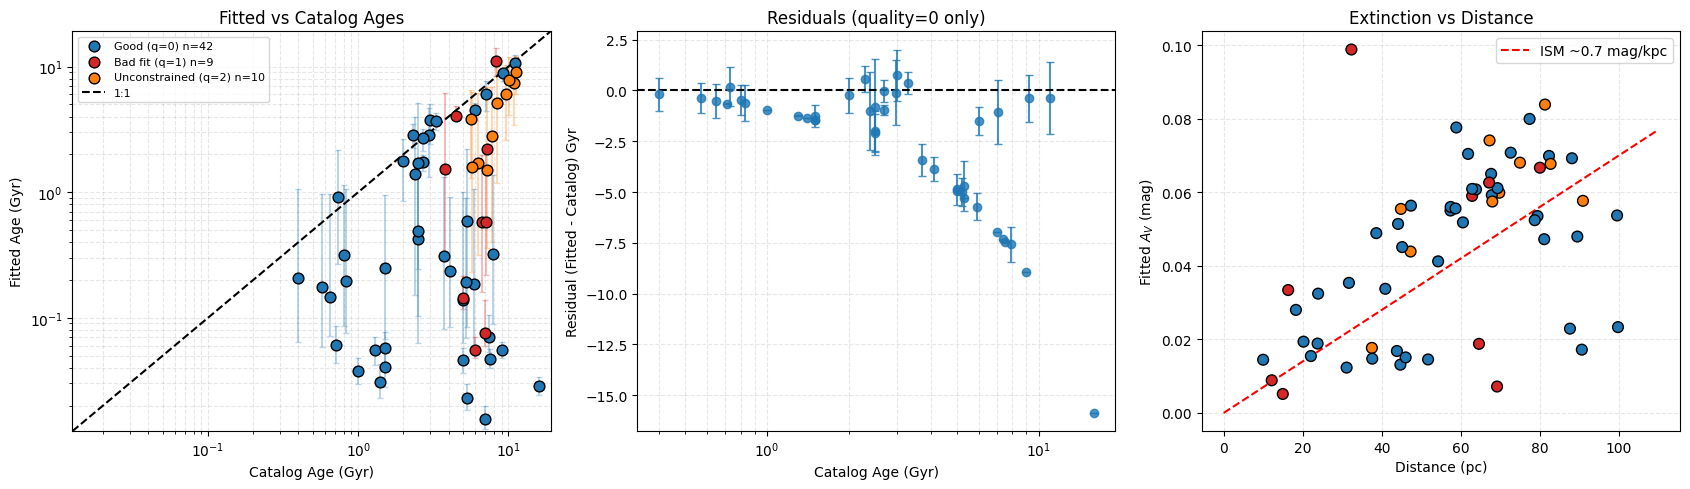

Quality flag summary:
  q=0 Good: 42
  q=1 Bad fit / non-convergence: 9
  q=2 Unconstrained: 10


In [94]:
df = results_df.copy()
df["residual"]     = df["age_median"] - df["age_catalog"]
df["abs_residual"] = df["residual"].abs()

# attach distance from merged_sample for the Av plot
dist_map = merged_sample.set_index("hostname")["distance_pc"]
df["distance_pc"] = df["hostname"].map(dist_map)

min_val = min(df["age_catalog"].min(), df["age_median"].min()) * 0.8
max_val = max(df["age_catalog"].max(), df["age_median"].max()) * 1.2
lims = [min_val, max_val]

# color by quality flag
quality_colors = {0: "tab:blue", 1: "tab:red", 2: "tab:orange"}
colors = df["quality"].map(quality_colors)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# panel 1: fitted vs catalog
ax = axes[0]
for q, label, c in [(0, "Good (q=0)", "tab:blue"),
                    (1, "Bad fit (q=1)", "tab:red"),
                    (2, "Unconstrained (q=2)", "tab:orange")]:
    sub = df[df["quality"] == q]
    if len(sub) == 0:
        continue
    ax.scatter(sub["age_catalog"], sub["age_median"],
               color=c, s=60, edgecolor="k", zorder=3, label=f"{label} n={len(sub)}")
    ax.errorbar(sub["age_catalog"], sub["age_median"],
                yerr=[sub["age_median"] - sub["age_lo"], sub["age_hi"] - sub["age_median"]],
                fmt="none", color=c, alpha=0.3, capsize=2)
ax.plot(lims, lims, "k--", lw=1.5, label="1:1")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lims);    ax.set_ylim(lims)
ax.set_xlabel("Catalog Age (Gyr)")
ax.set_ylabel("Fitted Age (Gyr)")
ax.set_title("Fitted vs Catalog Ages")
ax.legend(fontsize=8); ax.grid(True, which="both", ls="--", alpha=0.3)

# panel 2: residuals (quality=0 only — bad fits skew the plot)
ax = axes[1]
good = df[df["quality"] == 0]
ax.errorbar(good["age_catalog"], good["residual"],
            yerr=good["age_err"], fmt="o", capsize=3, alpha=0.8, color="tab:blue")
ax.axhline(0, color="k", ls="--", lw=1.5)
ax.set_xscale("log")
ax.set_xlabel("Catalog Age (Gyr)")
ax.set_ylabel("Residual (Fitted - Catalog) Gyr")
ax.set_title("Residuals (quality=0 only)")
ax.grid(True, which="both", ls="--", alpha=0.3)

# panel 3: Av vs distance
ax = axes[2]
df_dist = df.dropna(subset=["distance_pc"])
ax.scatter(df_dist["distance_pc"], df_dist["Av_median"],
           c=df_dist["quality"].map(quality_colors),
           edgecolor="k", s=60, zorder=3)
d_range = np.linspace(0, 110, 100)
ax.plot(d_range, 0.0007 * d_range, "r--", label="ISM ~0.7 mag/kpc")
ax.set_xlabel("Distance (pc)")
ax.set_ylabel(r"Fitted $A_V$ (mag)")
ax.set_title("Extinction vs Distance")
ax.legend(); ax.grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.savefig("/Users/elenadickens/Desktop/ASTR_502/plots/pipeline_apr7_61stars.png",
            dpi=150, bbox_inches="tight")
plt.show()

# quality summary
print("Quality flag summary:")
for q, desc in [(0, "Good"), (1, "Bad fit / non-convergence"), (2, "Unconstrained")]:
    print(f"  q={q} {desc}: {(df['quality']==q).sum()}")

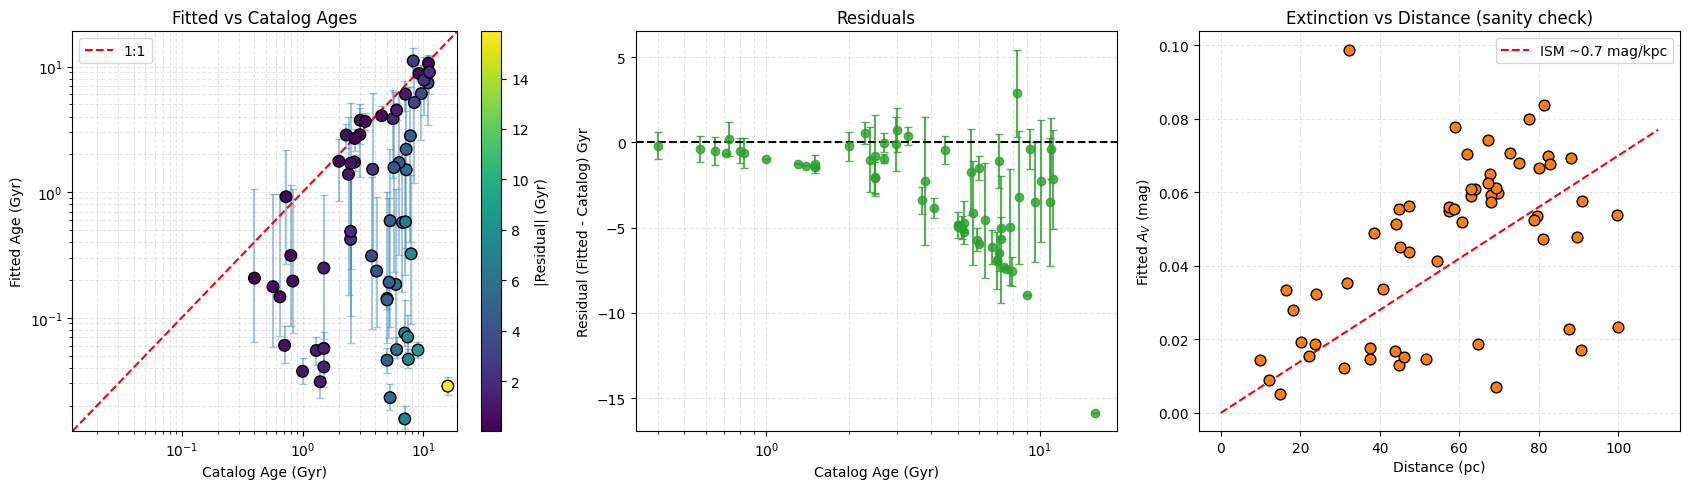

In [95]:
df = results_df.copy()
df["residual"]     = df["age_median"] - df["age_catalog"]
df["abs_residual"] = df["residual"].abs()

min_val = min(df["age_catalog"].min(), df["age_median"].min()) * 0.8
max_val = max(df["age_catalog"].max(), df["age_median"].max()) * 1.2
lims = [min_val, max_val]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# panel 1: fitted vs catalog
ax = axes[0]
sc = ax.scatter(
    df["age_catalog"], df["age_median"],
    c=df["abs_residual"], cmap="viridis", s=70, edgecolor="k", zorder=3
)
ax.errorbar(
    df["age_catalog"], df["age_median"],
    yerr=[df["age_median"] - df["age_lo"], df["age_hi"] - df["age_median"]],
    fmt="none", alpha=0.4, capsize=3
)
ax.plot(lims, lims, "r--", lw=1.5, label="1:1")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lims);    ax.set_ylim(lims)
fig.colorbar(sc, ax=ax, label="|Residual| (Gyr)")
ax.set_xlabel("Catalog Age (Gyr)")
ax.set_ylabel("Fitted Age (Gyr)")
ax.set_title("Fitted vs Catalog Ages")
ax.legend(); ax.grid(True, which="both", ls="--", alpha=0.3)

# panel 2: residuals
ax = axes[1]
ax.errorbar(
    df["age_catalog"], df["residual"],
    yerr=df["age_err"], fmt="o", capsize=3, alpha=0.8, color="tab:green"
)
ax.axhline(0, color="k", ls="--", lw=1.5)
ax.set_xscale("log")
ax.set_xlabel("Catalog Age (Gyr)")
ax.set_ylabel("Residual (Fitted - Catalog) Gyr")
ax.set_title("Residuals")
ax.grid(True, which="both", ls="--", alpha=0.3)

# panel 3: fitted Av vs distance (sanity check)
ax = axes[2]
ax.scatter(
    merged_sample["distance_pc"].values, df["Av_median"],
    c="tab:orange", edgecolor="k", s=60, zorder=3
)
d_range = np.linspace(0, 110, 100)
ax.plot(d_range, 0.0007 * d_range, "r--", label="ISM ~0.7 mag/kpc")
ax.set_xlabel("Distance (pc)")
ax.set_ylabel(r"Fitted $A_V$ (mag)")
ax.set_title("Extinction vs Distance (sanity check)")
ax.legend(); ax.grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.savefig("/Users/elenadickens/Desktop/ASTR_502/plots/march30_results.png",
            dpi=150, bbox_inches="tight")
plt.show()

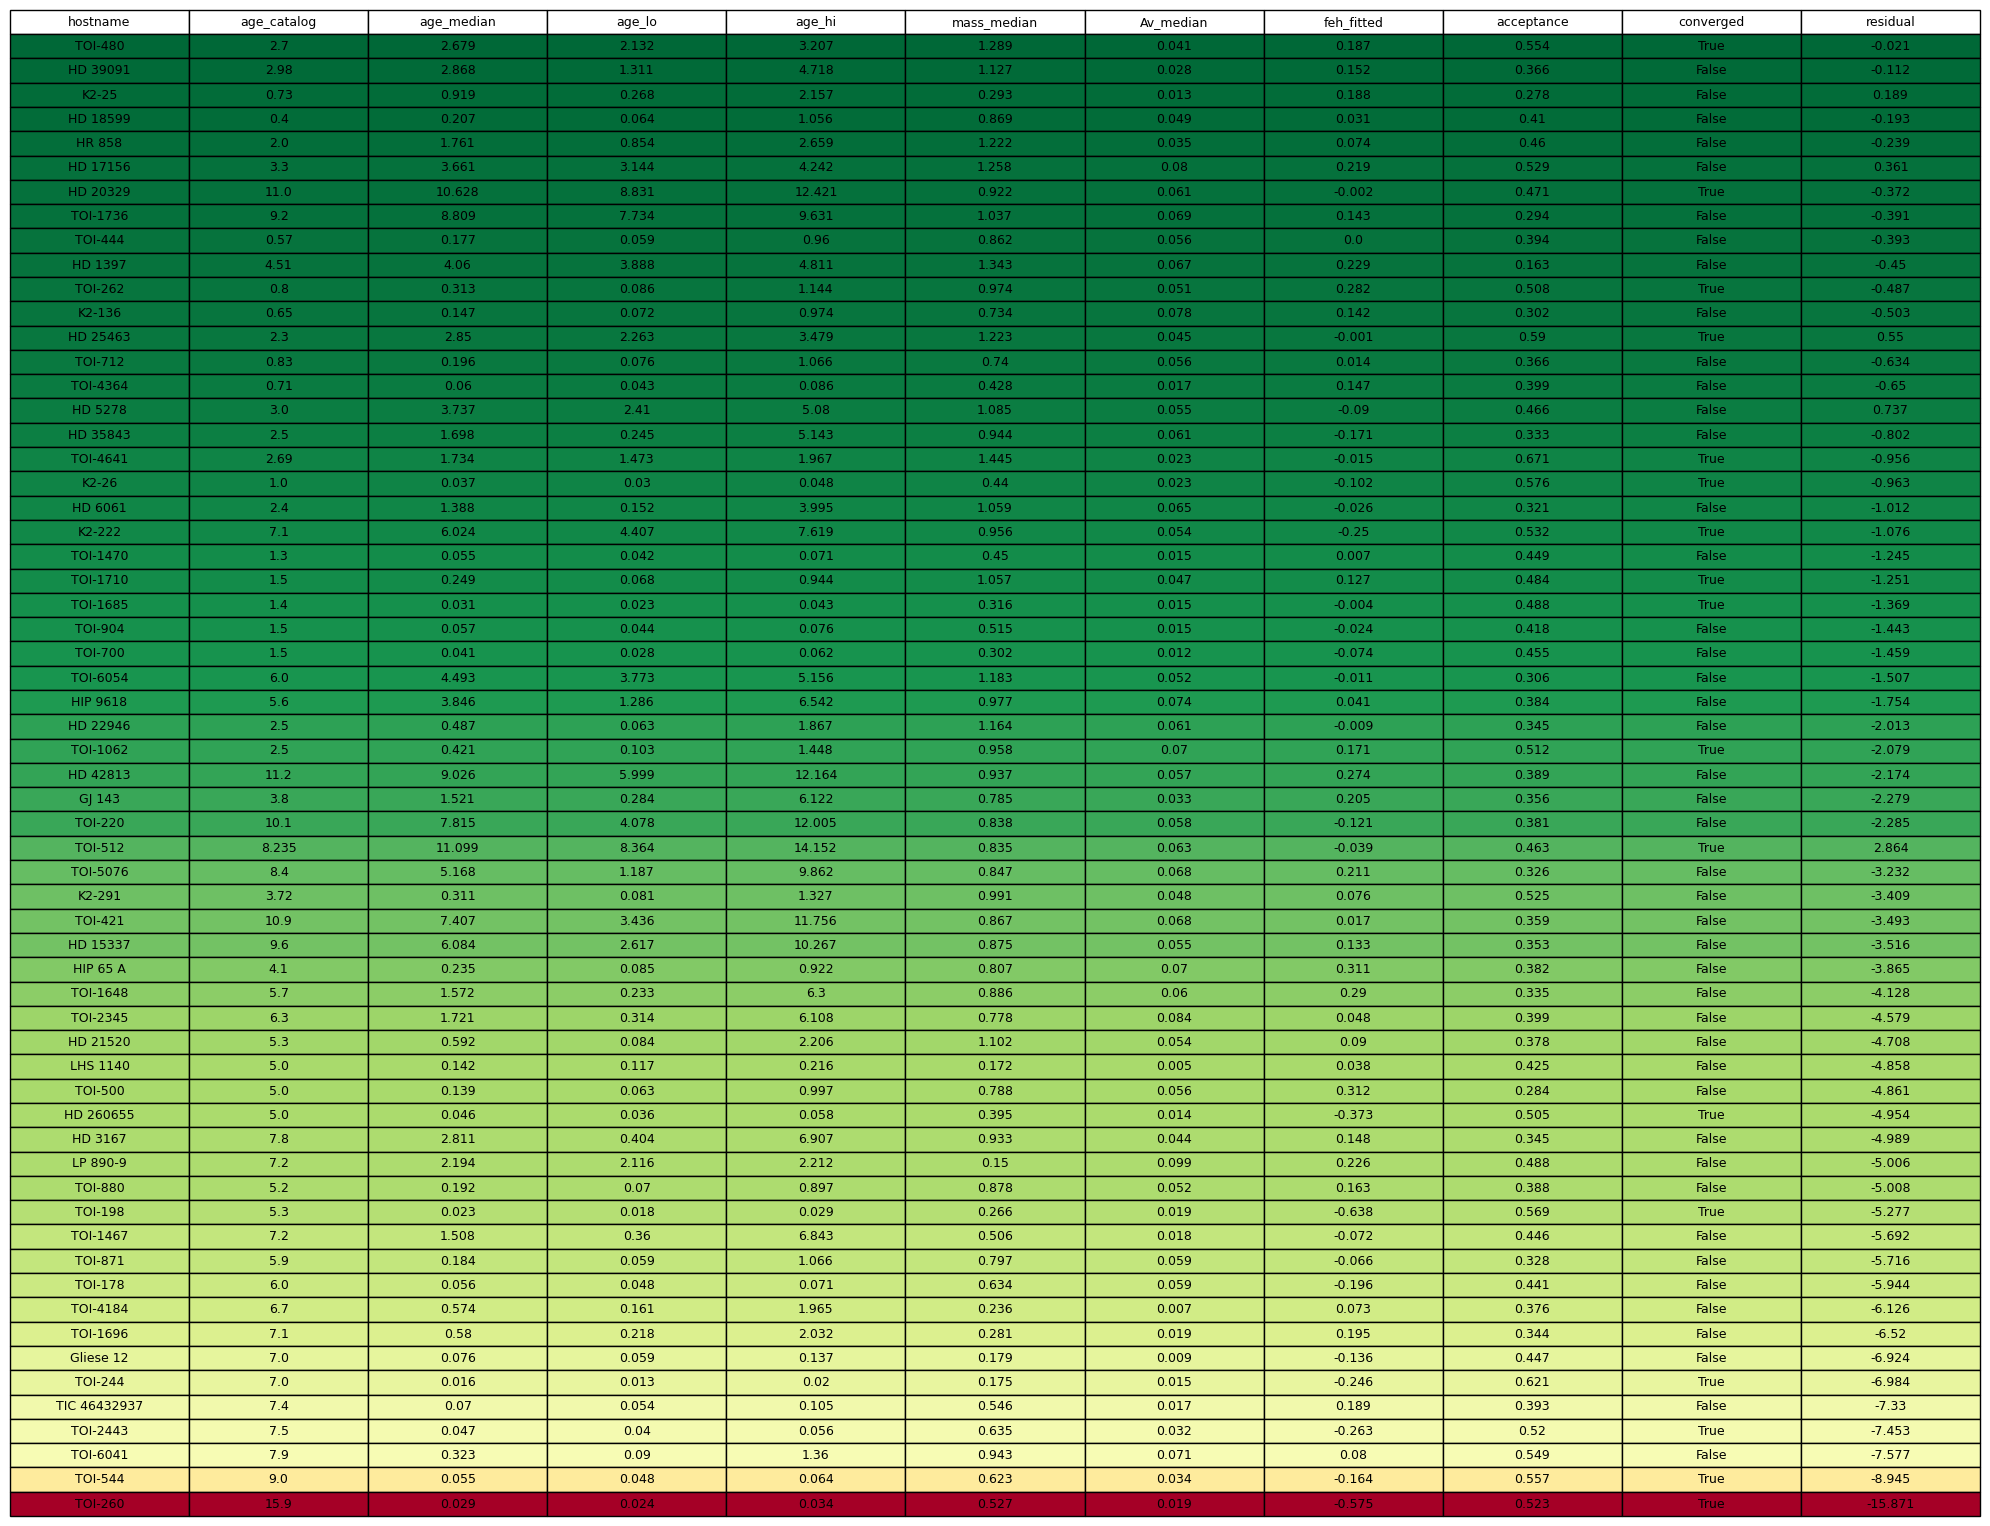

In [96]:
show_cols = [
    "hostname", "age_catalog", "age_median", "age_lo", "age_hi",
    "mass_median", "Av_median", "feh_fitted", "acceptance", "converged", "residual"
]
df_show = df.round(3).sort_values("abs_residual").reset_index(drop=True)[show_cols]

norm = plt.Normalize(df["abs_residual"].min(), df["abs_residual"].max())
cmap = plt.cm.RdYlGn_r

cell_colors = []
for _, row in df_show.iterrows():
    c = cmap(norm(abs(row["residual"])))
    cell_colors.append([c] * len(show_cols))

fig, ax = plt.subplots(figsize=(20, max(6, len(df_show) * 0.25)))
ax.axis("off")
tbl = ax.table(
    cellText=df_show.values,
    colLabels=df_show.columns,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
plt.tight_layout()
plt.show()

## 12. Corner Plot for a Single Star

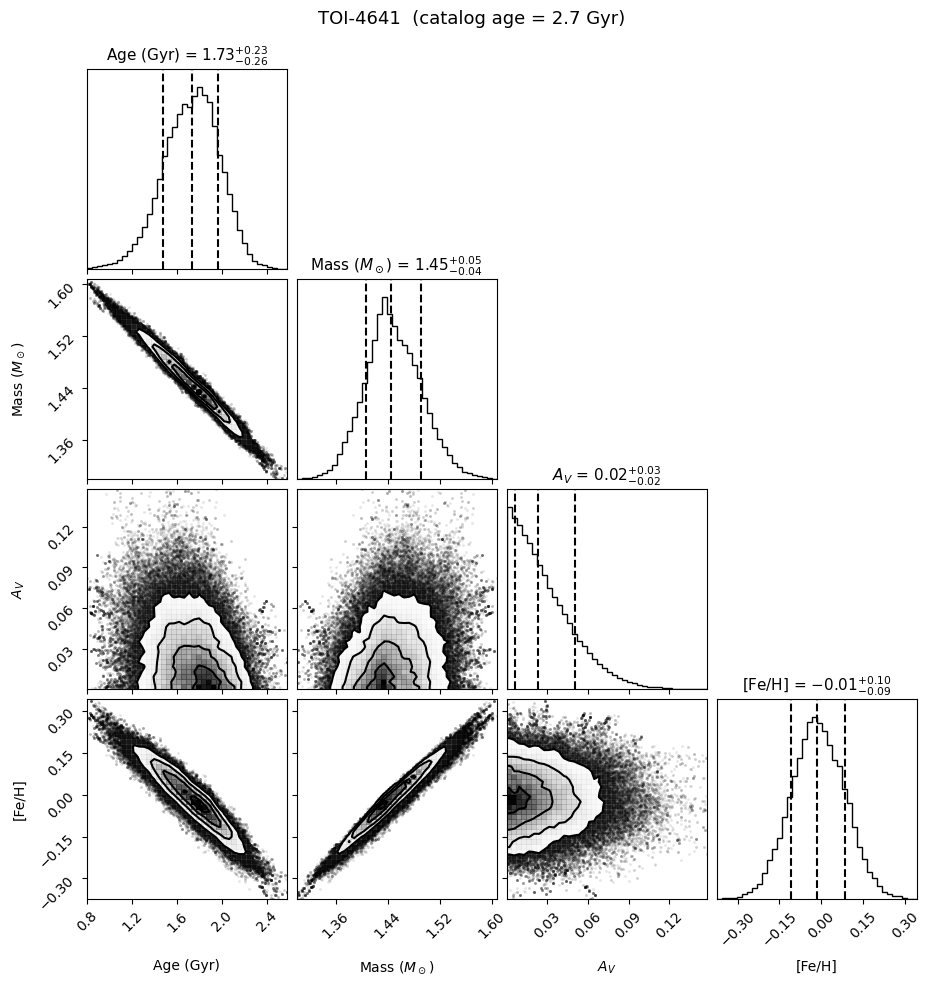

In [98]:
try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False
    print("corner not installed — run: pip install corner")

if HAS_CORNER and len(results_df) > 0:
    TARGET = results_df.iloc[20]["hostname"]   # change to any hostname in results
    idx    = results_df[results_df["hostname"] == TARGET].index[0]
    samps  = sample_list[idx].copy()
    samps[:, 0] = 10 ** samps[:, 0] / 1e9   # logage -> Gyr

    cat_age = results_df.loc[idx, "age_catalog"]

    fig = corner.corner(
        samps,
        labels=["Age (Gyr)", r"Mass ($M_\odot$)", r"$A_V$", "[Fe/H]"],
        truths=[cat_age, None, None, None],
        truth_color="red",
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 11},
        bins=40,
    )
    fig.suptitle(f"{TARGET}  (catalog age = {cat_age:.1f} Gyr)",
                 fontsize=13, y=1.02)
    plt.show()